# Future Earth Satellite Coverage Model

This Earth Satellite Coverage Model is built atop of the [Satellite Propagation Toolkit](https://github.com/rufusclark/Satellite-Propagation-Toolkit). To execute place and run this file from the root directory of the toolkit.

Comments, Limitations and Considerations
- The data presented in this analysis is for a single time point and the distribution of satellite throughout the Earth varies greatly as a function of time
- This model does not take into account the actual observation angle of optics, but rather uses the estimated observable angle, thus overestimating the area actually observed
- This model uses all satellites under the CelesTrak "Weather & Earth Resources Satellites" header
- The satellite set is made of 2 components which allows the model to still provide a "fairly" representative future set of satellites given the sub 2000km limitation of the MOCAT tool:
  - Under 2000km, a distribution of satellites based on the current distribution using MOCAT
  - Above 2000km, current satellites are used

In [1]:
# install dependencies
%pip install -r requirements.txt
%pip install cartopy

# restart kernel (with new dependencies)
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.kernel.restart()'))

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<IPython.core.display.Javascript object>

In [2]:
# import all dependencies
from src import init_sats, SGP4Propagation, plot_orbital_overview, OrbitalPosition, future
from src.const import EARTH_RADIUS

from datetime import datetime, time
import numpy as np

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod

plt.style.use("default")
plt.rcParams.update({
    "mathtext.fontset": "cm",  # Computer Modern
    "font.family": "serif"
})

In [3]:
# Import satellite data

# Import all sats
sats = init_sats(update_sources=False)

# Number of sats
total_sats = len(sats)
print(sats)

# Print out all satellite categories
sats.print_all_categories()

Using cached source groups
Loaded all 54 NORAD data sources                                                     
Loaded satcat.csv SATCAT data source
<Sats n=13923>
{'communications satellites': 10982,
 'miscellaneous satellites': 68,
 'navigation satellites': 164,
 'scientific satellites': 56,
 'special-interest satellites': 2147,
 'weather & earth resources satellites': 506}


In [4]:
# Filter sats

# propagation time - you want this to be within 2 weeks +/- of current data epoch or the output will be unreliable
t = datetime.combine(datetime(2025, 11, 27).date(), time(12)) # today at noon

# Filter sats based on category
filtered_sats = sats.filter(lambda sat: sat.category == "weather & earth resources satellites")

# Number of sats
num_filtered_sats = len(filtered_sats)
print(f"{filtered_sats=}")

# FIlter sats to only get sats above LEO (2000km)
above_leo_sats = filtered_sats.filter(lambda sat: SGP4Propagation()._propagate(sat, t).geo.alt > 2000)
below_leo_sats = filtered_sats.filter(lambda sat: SGP4Propagation()._propagate(sat, t).geo.alt < 2000)

print(f"{above_leo_sats=}\n{below_leo_sats=}")

filtered_sats=<Sats n=506>
above_leo_sats=<Sats n=119>
below_leo_sats=<Sats n=387>


In [ ]:
# generate new set of satellites
future_sats_leo = future.MOCATReader("./data/MOCAT/results_Su_max_launch_2025.csv").read_yrs(30).to_SatelliteSet(below_leo_sats, training_set_bias=0.8)

# limit the number of future_sats to a representative number of "weather & earth resources satellites" (not all MOCAT predicted satellites)
future_sats_leo = future_sats_leo.limit(int(len(future_sats_leo) * (num_filtered_sats/total_sats)))

# number of future_sats_leo
print(f"{future_sats_leo=}")

# combine MOCAT predicted LEO sats with current above LEO sats
future_sats = above_leo_sats + future_sats_leo

# number of future sats
print(f"{future_sats=}")

# sats = future_sats
sats = future_sats_leo

Reading MOCAT output: ./data/MOCAT/results_Su_max_launch_2025.csv
Generating OrbitalCapacity for 30.03003 (closest modelled year to target year of 30)
[<AltitudeBand min=200.0km max=250.0km capacity=947.67538 density=18.9535/km>, <AltitudeBand min=250.0km max=300.0km capacity=486.34225 density=9.7268/km>, <AltitudeBand min=300.0km max=350.0km capacity=274.5378 density=5.4908/km>, <AltitudeBand min=350.0km max=400.0km capacity=862.22791 density=17.2446/km>, <AltitudeBand min=400.0km max=450.0km capacity=449.77817 density=8.9956/km>, <AltitudeBand min=450.0km max=500.0km capacity=2801.0407 density=56.0208/km>, <AltitudeBand min=500.0km max=550.0km capacity=1487.7856 density=29.7557/km>, <AltitudeBand min=550.0km max=600.0km capacity=2662.2743 density=53.2455/km>, <AltitudeBand min=600.0km max=650.0km capacity=250.0357 density=5.0007/km>, <AltitudeBand min=650.0km max=700.0km capacity=149.96278 density=2.9993/km>, <AltitudeBand min=700.0km max=750.0km capacity=99.957547 density=1.9992/km>

In [7]:
# Get satellite position at given time

# Get position at a given time
positions = SGP4Propagation().propagate(future_sats_leo, t)
print(sorted([pos.geo.alt for pos in positions]))

[np.float64(185.52078885071137), np.float64(211.3501241053246), np.float64(215.73381544090702), np.float64(219.85153037765883), np.float64(220.6300870686001), np.float64(222.1436558353046), np.float64(222.44896592771013), np.float64(226.29151340444116), np.float64(230.16750541231931), np.float64(232.5269079634747), np.float64(234.95168925394069), np.float64(236.80317774082457), np.float64(237.18900150049777), np.float64(239.6186707840627), np.float64(241.96342077417648), np.float64(243.885093907417), np.float64(245.0775993075468), np.float64(246.23459465183123), np.float64(246.4612306528185), np.float64(248.8829797076297), np.float64(249.16504340051554), np.float64(251.4023712238355), np.float64(252.28656252106677), np.float64(253.6608152929633), np.float64(253.8413424480481), np.float64(253.88928400831355), np.float64(254.78122320525918), np.float64(255.14298228870655), np.float64(255.42475619439796), np.float64(257.48851298894914), np.float64(258.20843093598137), np.float64(259.07273

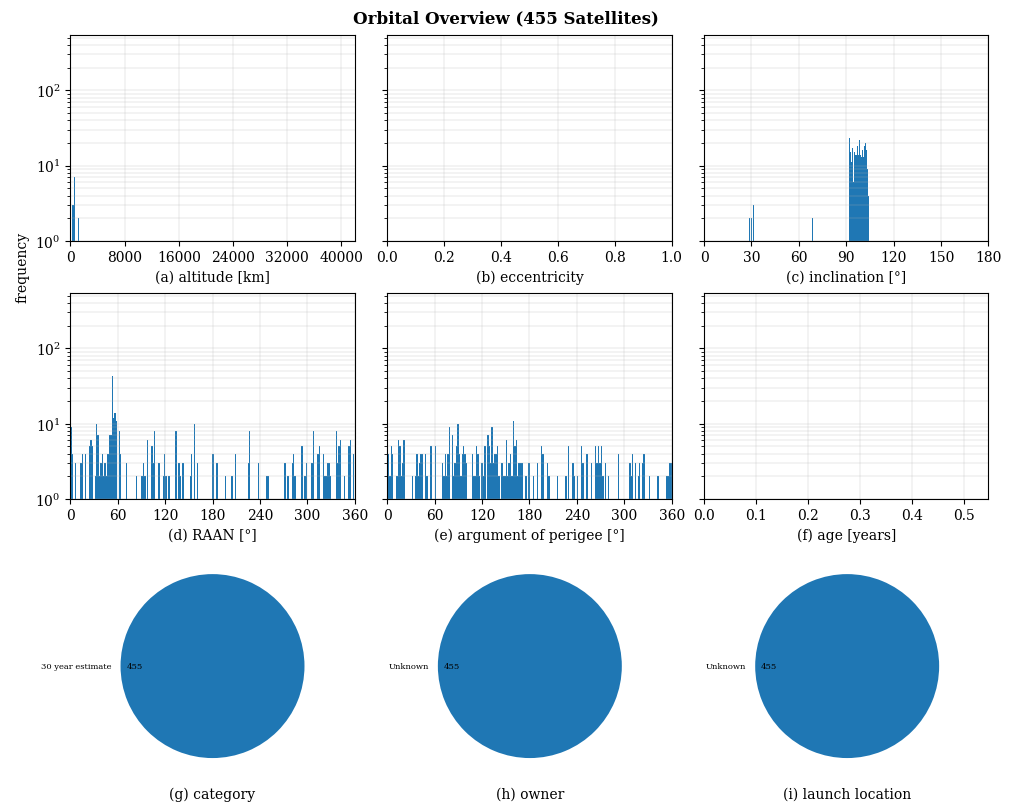

In [8]:
# Optionally, plot orbital overview

plot_orbital_overview(positions)

In [9]:
# process orbital position data and calculate ground radius

def half_angle(position: OrbitalPosition) -> float:
    """lookup half angle based on Ciara data on constellations field of view"""
    # Ciara data
    lookup_dict = {"FLOCK": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "SKYSAT": {"FoV half angle degs": 7.5, "night mode": False, "instrument": "optical"}, "ICEYE": {"FoV half angle degs": 4.5, "night mode": True, "instrument": "radar"}, "CAPELLA": {"FoV half angle degs": 15, "night mode": True, "instrument": "radar"}, "SENTINEL": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}, "WORLDVIEW": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "OTHER": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}}
    lookup_dict_keys = list(lookup_dict.keys())
    constellation = position.sat.constellation

    return lookup_dict[constellation if constellation in lookup_dict_keys else "OTHER"]["FoV half angle degs"]

# create numpy array for latitude, longitude and ground radius of each sat
latitudes = np.array([position.geo.lat for position in positions])
longitudes = np.array([position.geo.lon for position in positions])
ground_radius = np.array([position.geo.swath_ground_radius(half_angle(position)) for position in positions])

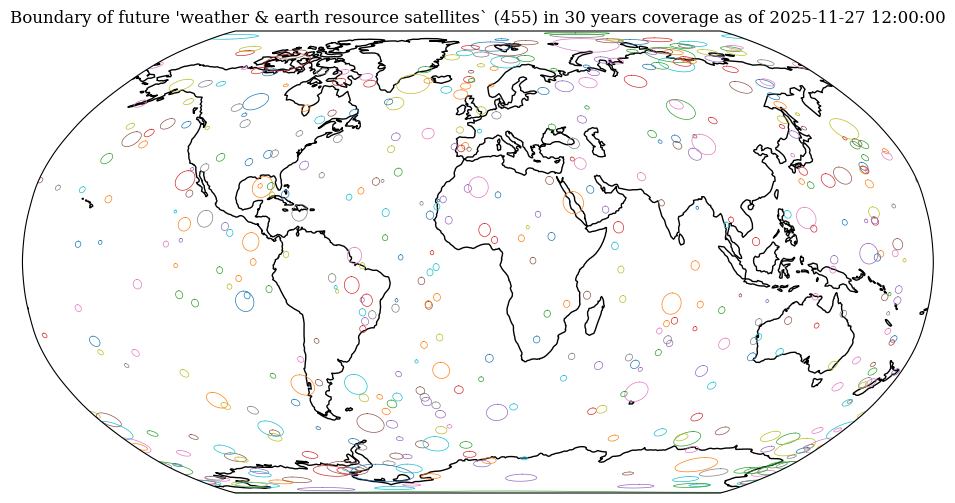

In [10]:
# Plot the boundary of coverage on a 2D map

# Earth model for geodesics
geod = Geod(ellps="WGS84")

def geodesic_circle(lon0, lat0, radius_km, n=360):
    # Ensure lon0, lat0, radius are scalars (very important)
    lon0 = float(lon0)
    lat0 = float(lat0)
    radius_m = float(radius_km) * 1000.0

    # Bearings 0–360°
    az = np.linspace(0, 360, n)

    # Create *matching-length* arrays
    lon0_arr = np.full_like(az, lon0, dtype=float)
    lat0_arr = np.full_like(az, lat0, dtype=float)
    dist_arr  = np.full_like(az, radius_m, dtype=float)

    lon, lat, _ = geod.fwd(lon0_arr, lat0_arr, az, dist_arr)

    return lon, lat

# Plot
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

for sat_lats, sat_lons, r in zip(latitudes, longitudes, ground_radius):
    c_lon, c_lat = geodesic_circle(sat_lons, sat_lats, r)
    ax.plot(c_lon, c_lat, transform=ccrs.Geodetic(), linewidth=0.5)

plt.title(f"Boundary of future 'weather & earth resource satellites` ({len(sats)}) in 30 years coverage as of {t}")

plt.show()

In [11]:
# define fibonacci grid - almost perfectly distributed points on a sphere
# https://extremelearning.com.au/how-to-evenly-distribute-points-on-a-sphere-more-effectively-than-the-canonical-fibonacci-lattice/

resolution_km = 25

# calculate the number of points needed
n = np.ceil((4 * np.pi * EARTH_RADIUS**2)/(resolution_km)**2)
print(f"Total grid points: {n:.0f}")

# generate fibonacci sphere coordinates
i = np.arange(n)
golden_ratio = (1 + 5**0.5)/2
theta = 2 * np.pi * i / golden_ratio
phi = np.arccos(1 - 2*(i)/n)

# convert to spherical coordinates
x, y, z = np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)

# convert to lat/lon (degrees)
grid_lats = np.degrees(np.arcsin(y))
grid_lons = np.degrees(np.arctan2(z, x))

Total grid points: 816104


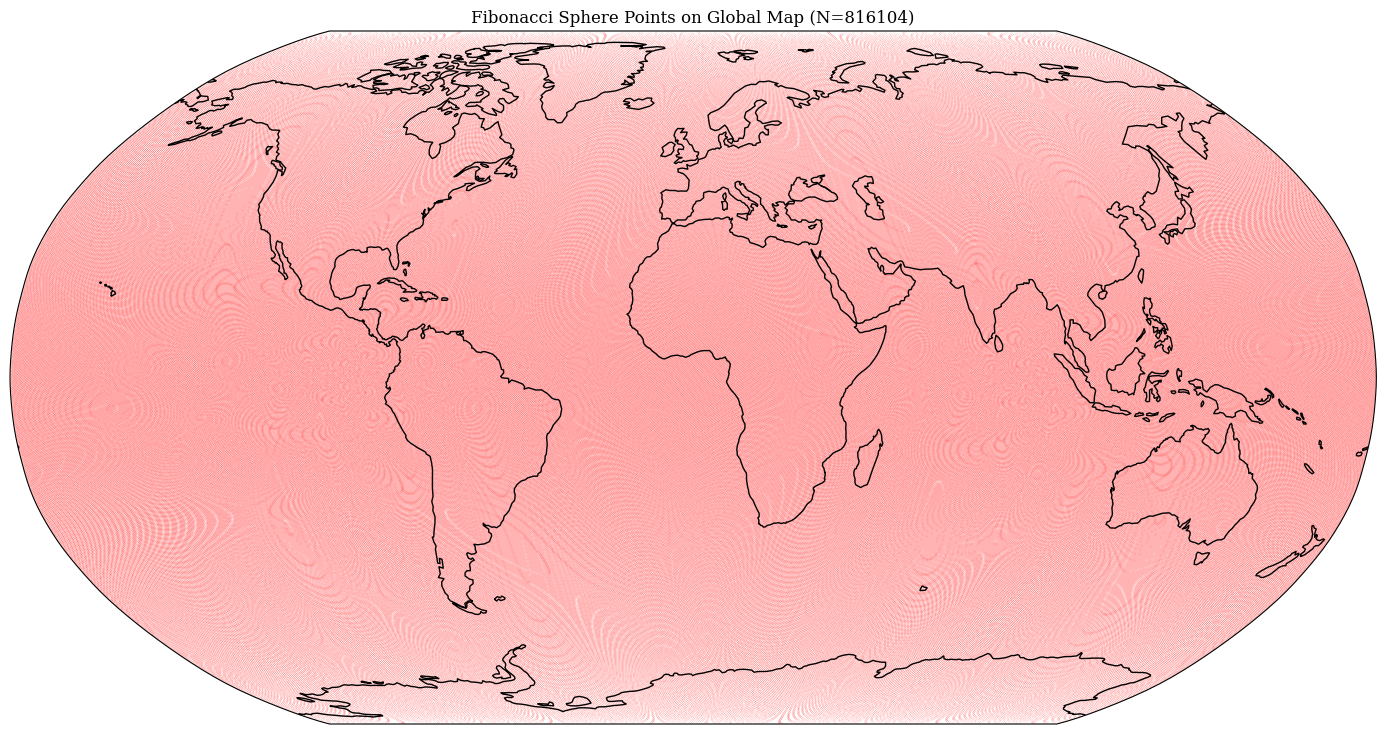

In [12]:
# plot fibonacci grid

# Plot
fig = plt.figure(figsize=(18, 9))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

# Plot the points
ax.scatter(grid_lons, grid_lats, s=0.005, color='red',alpha=0.7,transform=ccrs.Geodetic())

plt.title(f"Fibonacci Sphere Points on Global Map (N={len(grid_lats)})")
plt.show()

In [13]:
# coverage calculations

def great_circle_distance(lat1, lon1, lat2, lon2):
    """computes the great-circle distance in kilometres.

    uses the spherical law of cosines (accurate when distance is > 1m) otherwise you haversine formula

    typical error vs WGS-64 Ellipsoid is 0.1%-0.5%
    """

    dlon = lon2 - lon1

    return EARTH_RADIUS * np.acos(
        np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(dlon)
    )

coverage = np.zeros(grid_lons.shape, dtype=np.int16)

# precompute values for great circle calculations
grid_lats_rad = np.radians(grid_lats)
grid_lons_rad = np.radians(grid_lons)

for sat_lat, sat_lon, sat_r in zip(latitudes, longitudes, ground_radius):

    # performance optimisations

    # pre-convert
    sat_lat_rad = np.radians(sat_lat)
    sat_lon_rad = np.radians(sat_lon)

    # bounding box calculations
    central_angle = sat_r / EARTH_RADIUS

    # latitude mask
    mask = np.abs(grid_lats_rad - sat_lat_rad) <= central_angle

    # skip if no points in bounding box
    if not np.any(mask):
        continue

    # end of performance optimisations

    # Great circle distance
    dist = great_circle_distance(grid_lats_rad[mask], grid_lons_rad[mask], sat_lat_rad, sat_lon_rad)

    # check if grid point is within sat radius
    coverage[mask] += (dist <= sat_r).astype(np.int16)

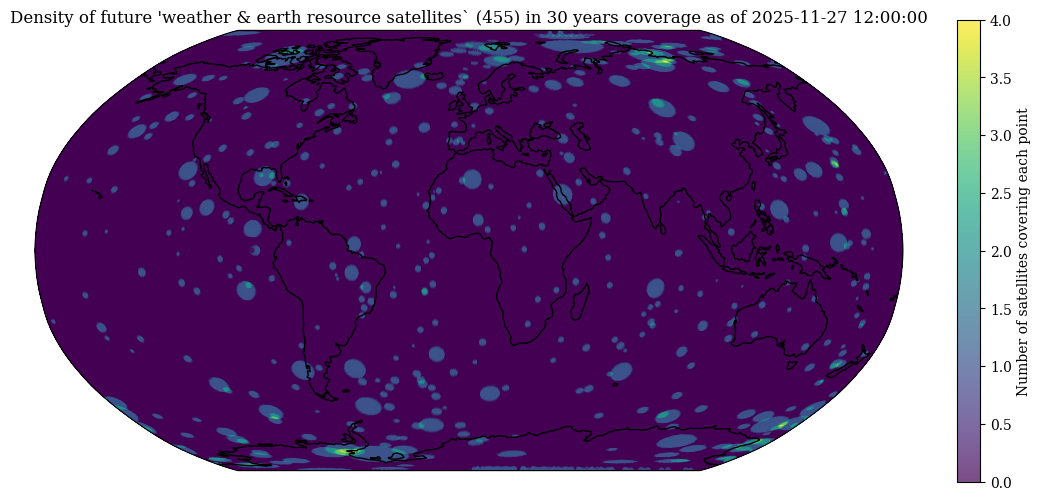

In [16]:
# Plot coverage

fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines()
sc = ax.scatter(grid_lons, grid_lats, c=coverage, s=10, cmap="viridis", alpha=0.7, transform=ccrs.Geodetic())
plt.colorbar(sc, orientation="vertical", label="Number of satellites covering each point")
plt.title(f"Density of future 'weather & earth resource satellites` ({len(sats)}) in 30 years coverage as of {t}")
plt.show()

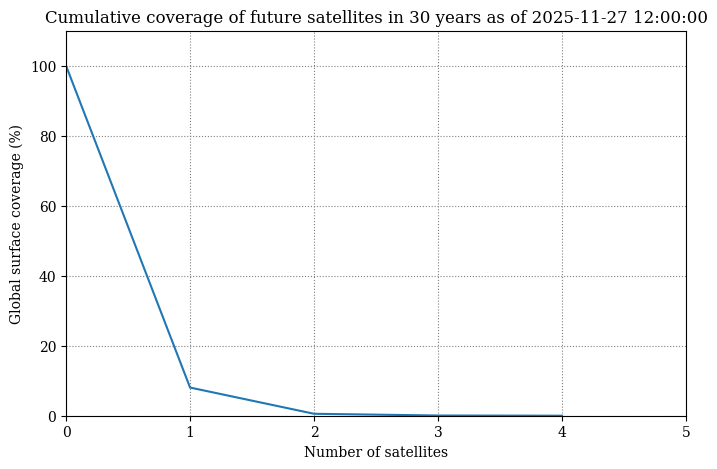

In [15]:
# Flatten coverage array
max_coverage = coverage.max()

# Compute counts for >= i satellites (no weighting)
counts = np.array([np.sum(coverage >= i) for i in range(1, max_coverage+1)])

# Convert to percentage of total grid points
cumulative_percent = counts / coverage.size * 100
num_sats = np.arange(1, max_coverage+1)

# Add data point (num_sats, cumulative_percent) = (0, 100) to clean up graph
num_sats = np.insert(num_sats, 0, 0)
cumulative_percent = np.insert(cumulative_percent, 0, 100)

# plot coverage cumulative frequency
plt.figure(figsize=(8,5))
plt.plot(num_sats, cumulative_percent)
plt.xlabel("Number of satellites")
plt.ylabel("Global surface coverage (%)")
plt.xlim(0, len(num_sats))
plt.ylim(0, 110)
plt.title(f"Cumulative coverage of future satellites in 30 years as of {t}")
plt.grid(True, linestyle=":", color="gray")
plt.show()